**временные ряды, модели регрессии, извлечение признаков**

Евгений Борисов <esborisov@sevsu.ru>

-----

Дмитрий Макаров   Временные ряды.    
https://www.dmitrymakarov.ru/intro/time-series-20/

Евгений Рябенко Прогнозирование временных рядов.     
https://www.youtube.com/watch?v=u433nrxdf5k



How To Create Time Series Features with tsfresh    
https://www.rasgoml.com/feature-engineering-tutorials/how-to-create-time-series-features-with-tsfresh`

-----

#  загружаем данные

In [1]:
import numpy as np
from numpy import random as rng
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# !yes|pip uninstall pystooq
# !yes| pip uninstall googlefinance 
# !yes| pip uninstall pandas_datareader 

In [3]:
# pip install  yfinance

In [ ]:
# # Data from Google Finance

# from pandas_datareader.data import DataReader
# # df = DataReader("AAPL", "stooq")
# # df = DataReader("GS", "stooq") 
# df = DataReader("IBM", 'stooq').reset_index()
# df = df[['Date','Close']].rename(columns={'Close':'values','Date':'date'})
# df = df.set_index('date').sort_index()

In [18]:
import yfinance as yf

df = yf.download('AAPL','2016-01-01','2019-12-28')
display(df.sample(4))

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-12-16,26.679829,26.801759,26.606210,26.794858,177404400
2019-12-19,67.437744,67.717110,67.180060,67.312514,98369200
2018-07-27,44.997883,45.989826,44.790543,45.942704,96096000
2019-03-28,44.969070,45.169229,44.685511,45.023875,83121600


In [19]:
df.columns= ['Close','High','Low','Open','Volume']
df = df.reset_index()
df = df[['Date','Close']].rename(columns={'Close':'values','Date':'date'})
df = df.set_index('date').sort_index()

display( df.head(10) )

,values
date,
2016-01-04,23.709106
2016-01-05,23.114971
2016-01-06,22.662611
2016-01-07,21.706152
2016-01-08,21.820925
2016-01-11,22.174257
2016-01-12,22.496086
2016-01-13,21.917696
2016-01-14,22.397053


In [ ]:
# # monthly totals of a US airline passengers from 1949 to 1960
# # 
# # AirPassengers.csv :
# #    https://drive.google.com/file/d/1yfw6gcgmJXCtxkjC69ekUvsEtAiYTlST/view?usp=share_link
# #    https://huggingface.co/spaces/Anniek/Time_series_forecast/raw/main/AirPassengers.csv

# url = 'https://huggingface.co/spaces/Anniek/Time_series_forecast/raw/main/AirPassengers.csv'
# df = pd.read_csv(url).convert_dtypes()

# df['date'] = pd.to_datetime(df['Month'])
# df = df.set_index('date')
# df = df.asfreq('MS')
# df = df[['#Passengers']].rename(columns={'#Passengers':'values'})
# df = df.sort_index()

# анализ данных

__1. визуальная оценка данных__

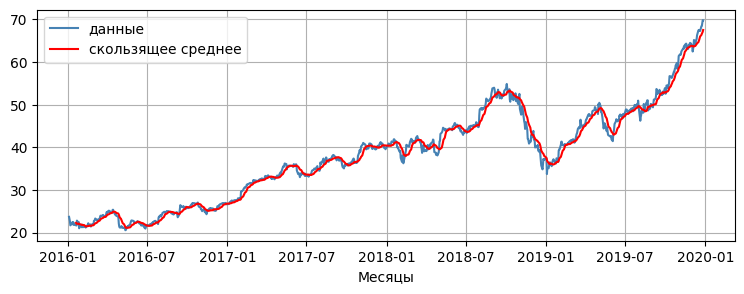

In [21]:
fig,ax = plt.subplots(figsize = (9,3))
ax.plot(df['values'], label = 'данные', color = 'steelblue')
ax.plot(df['values'].rolling(window=12).mean(), label = 'скользящее среднее', color = 'red')
#ax.plot(df['values'].rolling(window=7).mean(), label = 'скользящее среднее', color = 'red')
ax.set_xlabel('Месяцы', )
ax.legend(title = '', loc = 'upper left', )
ax.grid()

__оценка автокорреляции__

In [22]:
# pip install statsmodels

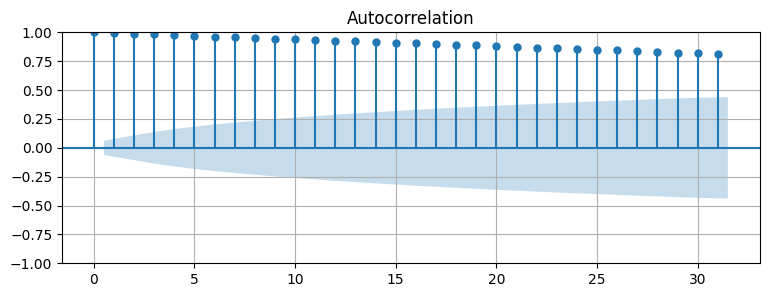

In [23]:
from statsmodels.graphics.tsaplots import plot_acf
fig,ax = plt.subplots(figsize = (9,3))
plot_acf(df['values'],ax=ax)
ax.grid()

# собираем датасет

In [24]:
display( df.index.min(), df.index.max(), )

Timestamp('2016-01-04 00:00:00')

Timestamp('2019-12-27 00:00:00')

In [29]:
df.index

DatetimeIndex(['2016-01-04', '2016-01-05', '2016-01-06', '2016-01-07',
               '2016-01-08', '2016-01-11', '2016-01-12', '2016-01-13',
               '2016-01-14', '2016-01-15',
               ...
               '2019-12-13', '2019-12-16', '2019-12-17', '2019-12-18',
               '2019-12-19', '2019-12-20', '2019-12-23', '2019-12-24',
               '2019-12-26', '2019-12-27'],
              dtype='datetime64[s]', name='date', length=1004, freq=None)

In [30]:
df_train, df_test = df[:'2018-12'],df['2019-01':]

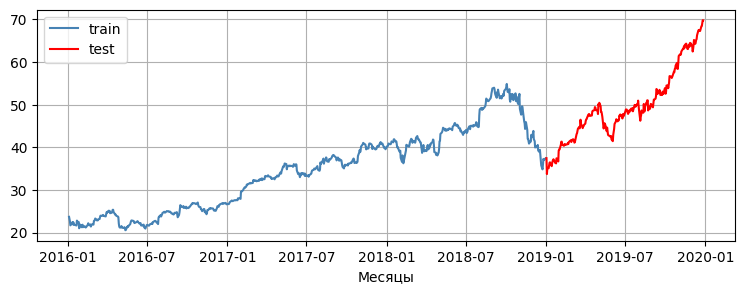

In [31]:
fig,ax = plt.subplots(figsize = (9,3))
ax.plot(df_train['values'], label = 'train', color = 'steelblue')
ax.plot(df_test['values'], label = 'test', color = 'red')
ax.set_xlabel('Месяцы', )
ax.legend(title = '', loc = 'upper left', )
ax.grid()

---

In [32]:
# pip install tsfresh 

In [33]:
import tsfresh
from tsfresh.utilities import dataframe_functions as F

модель “плавающего окна”,    
для каждого значения формируем  историю предыдущих значений,     
из этой истории строим признаки   

In [34]:
# размер окна, по которому будем строить прогноз
# window_size = 3 # месяцев
window_size = 7 # дней

In [35]:
# df

In [36]:
df_train.loc[:,'id'] = 0 # метка группы

df_train_roll = F.roll_time_series(
        df_train.reset_index(),
        column_id='id', 
        column_sort='date',
        #column_value='values',
        min_timeshift=window_size,
        max_timeshift=window_size, 
        # rolling_direction=1,
        # show_warnings=False,
        disable_progressbar=True,
        n_jobs=4,
    )

# метка группы
df_train_roll.loc[:,'id'] =  pd.to_datetime( df_train_roll['id'].str[1] )
df_train_roll = df_train_roll[ df_train_roll['id']!= df_train_roll['id'].max() ]

display( df_train_roll.head(12))

/home/mechanoid/projects/py/sevgu/.venv/lib/python3.14/site-packages/tsfresh/utilities/dataframe_functions.py:520: UserWarning: Your time stamps are not uniformly sampled, which makes rolling nonsensical in some domains.
  warnings.warn(


KeyError: 'id'

In [ ]:
target_train = df_train.iloc[window_size:]['values'].shift(-1).dropna()
display(target_train)

In [ ]:
%%time 

# df_train_features = tsfresh.extract_features(
#     df_train_roll.reset_index(), 
#     column_id='id', 
#     column_sort='date', 
#     column_value='values',
#     #default_fc_parameters=tsfresh.feature_extraction.MinimalFCParameters()
# )

# df_train_features = tsfresh.extract_features(
#     df_train_roll.reset_index(), 
#     column_id='id', 
#     column_sort='date', 
#     column_value='values',
#     default_fc_parameters=tsfresh.feature_extraction.MinimalFCParameters()
# )


df_train_features = tsfresh.extract_relevant_features(
    df_train_roll.reset_index(), 
    target_train,
    column_id='id',
    column_sort='date',
    column_value='values',
    show_warnings=False,
    disable_progressbar=False,
    n_jobs=4,
)

df_train_features = df_train_features.dropna(axis=1)

feature_settings =  tsfresh.feature_extraction.settings.from_columns(df_train_features)
feature_order = df_train_features.columns

display( len(df_train_features) )
display( df_train_features.sample(3) )
display( list(feature_order) )

In [ ]:
df_test.loc[:,'id'] = 0 # метка группы
df_test_roll = F.roll_time_series(
        df_test.reset_index(),
        column_id='id', 
        column_sort='date',
        #column_value='values',
        min_timeshift=window_size,
        max_timeshift=window_size, 
        # rolling_direction=1,
        # show_warnings=False,
        disable_progressbar=True,
        n_jobs=4,
    )

df_test_roll = df_test_roll[ df_test_roll['id']!= df_test_roll['id'].max() ]

# метка группы
df_test_roll.loc[:,'id'] =  pd.to_datetime( df_test_roll['id'].str[1] )

# display( df_test_roll.head(12))

df_test_features = tsfresh.extract_features(
        df_test_roll, 
        default_fc_parameters=feature_settings['values'],
        column_id='id', 
        column_sort='date',
        column_value='values',
        disable_progressbar=True,
        impute_function=F.impute, 
        show_warnings=False,
        n_jobs=4,
    )[feature_order]

#display( len(df_test_features) )
#display( df_test_features.sample(3) )

target_test = df_test.iloc[window_size:]['values'].shift(-1).dropna()
#display(target_test)

# обучаем модель

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly =  PolynomialFeatures( 
        degree=1, 
        interaction_only=False, 
        include_bias=True,
    ).fit( df_train_features.values )

x = poly.transform( df_train_features.values  )

predicted_train = target_train.to_frame()
y = np.array(target_train.values,dtype=np.float32)

display( x.shape, y.shape )

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression().fit(x,y)

In [ ]:
predicted_train['predicted train'] = model.predict(x)
predicted_train = predicted_train.rename(columns={'values':'train data'})

# тестируем

In [ ]:
predicted_test = target_test.to_frame()
x = poly.transform( df_test_features.values  )

predicted_test['predicted test'] = model.predict(x)
predicted_test = predicted_test.rename(columns={'values':'test data'})

In [ ]:
fig,ax = plt.subplots(figsize = (11,5))
predicted_train[['train data']].plot(ax=ax,alpha=.5)
predicted_test[['test data']].plot(ax=ax,alpha=.5)

predicted_train[['predicted train']].plot(ax=ax,alpha=.5,)
predicted_test[['predicted test']].plot(ax=ax,alpha=.5,)

ax.grid()
ax.legend()

In [ ]:
from sklearn.metrics import mean_squared_error

display( mean_squared_error( predicted_train['train data'], predicted_train['predicted train']) )
display( mean_squared_error( predicted_test['test data'], predicted_test['predicted test']) )